# CUT MATERIAL from the Calculus tutorial

## Example: file download

Suppose you're downloading a $720$\[MB\] file from the internet to your
computer. At $t=0$ you click "Save as" to start the download.
Let's denote $f(t)$ the disk space occupied by
the partially-downloaded file at time $t$.

#### Download rate

The *derivative function* $f^{\prime\!}(t)$, pronounced "$f$ prime,"
describes how the file size $f(t)$ changes over time.
In our example,
$f^{\prime\!}(t)$ is the download speed. If your download speed is
$f^{\prime\!}(t)=2$\[MB/s\], then the file size $f(t)$ will increase by
2\[MB\] each second. If you maintain this download speed, the file size
will grow at a constant rate: $f(0)=0$\[MB\], $f(1)=2$\[MB\],
$f(2)=4$\[MB\], $\ldots$, $f(100)=200$\[MB\],
and so on until $f(360) = 720$\[MB\],
and the download is complete.

To estimate the time that remains before the download completes,
assuming the current speed stays roughly constant, we can divide the
amount of data that remains to be downloaded by the current download
speed:

$$\text{time remaining at } t = \tfrac{ 720 - f(t) }{ f^{\prime\!}(t) } \quad [\textrm{s}].$$

The bigger the derivative $f^{\prime\!}(t)$, the faster the download
will finish. If your internet connection were 10 times faster, the
download would finish 10 times more quickly.

Let's encode this formula as a Python function
that takes the current file size $f(t)$
and download rate $f'(t)$ as inputs
and computes the time remaining before the download completes.

In [1]:
fprime = 2  # MB/s

def time_remaining(current_size, fprime=2):
    return (720 - current_size) / fprime

We can use this function to check the time remaining
at start of the download.

In [2]:
time_remaining(current_size=0, fprime=2)

360.0

In [3]:
# After 200MB downloaded
time_remaining(current_size=200, fprime=2)

260.0

In [4]:
# After 200MB downloaded, but 10x download speed
time_remaining(current_size=200, fprime=20)

26.0

#### Inverse problem

Let's now consider the download scenario from the point of view of the
modem that connects your computer to the internet. Any data you download
comes through the modem, so the modem knows the download rate
$f^{\prime\!}(t)$\[MB/s\] at all times during the download. The modem is
separate from your computer, so it doesn't know the file size $f(t)$.
Nevertheless, the modem can infer the file size at time $t$ from the
transmission rate $f^{\prime\!}(t)$. Think about it—if the modem sees
data flowing through at the rate of $f^{\prime\!}(t)=2$\[MB/s\], then it
knows that the data accumulated on your computer is growing at the rate
of $2$\[MB\] each second.We can describe the total file size
accumulated between $t=0$ and $t=\tau$ (the Greek letter *tau*) as the
*integral* of the download rate $f^{\prime\!}(t)$ from $t=0$ until $t=\tau$:

$$f(\tau) \; = \; \int_{t=0}^{t=\tau}  f^{\prime\!}(t)\, dt.$$

The symbol $\int$ is an elongated $S$ that stands for *sum*. Indeed, the
"integral of $f^{\prime\!}(t)$ between $0$ and $\tau$" is in some sense
the sum of $f^{\prime\!}(t)$ during each time instant $dt$ between $t=0$
and $t=\tau$. To calculate the total accumulated file size, we split the
time interval between $t=0$ and $t=\tau$ into many short time intervals
$dt$ of length $1$\[s\]. During each second, the file size grows by
$f^{\prime\!}(t)\,dt$, where $f^{\prime\!}(t)$ is the download rate
measured in \[MB/s\], and $dt$ is a time interval of duration $1$\[s\].

In [5]:
def file_size(tau, fprime=2):
    dt = 1  # 1 second time intervals
    return sum([fprime*dt for t in range(0,tau)])

# After 10 seconds...
file_size(10, fprime=2)

20

In [6]:
# After 360 seconds...
file_size(360, fprime=2)

720

#### Example 5

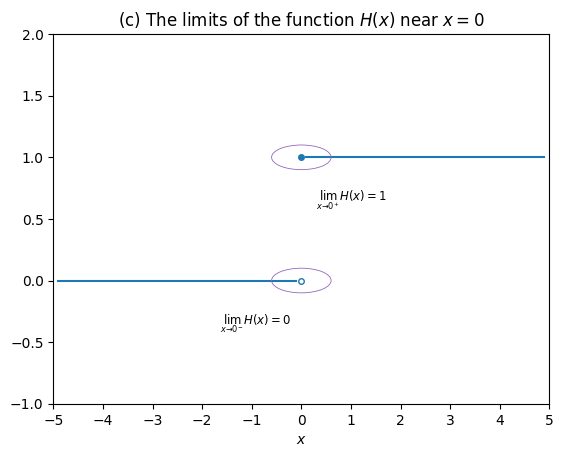

In [7]:
from ministats.calculus import plot_limit
from ministats.calculus import plot_ellipse
from ministats.calculus import plot_integral

# (c) Limits involving the Heaviside step function f(x) = H(x)
def H(x):
    if x >= 0:
        return 1
    else:
        return 0

ax = plot_limit(H, xlim=[[-5,0],[0,5]], eps=0.1, ylim=[-1,2])
ax.set_xticks([-5,-4,-3,-2,-1,0,1,2,3,4,5])
ax.set_xlabel("$x$")
ax.set_title("(c) The limits of the function $H(x)$ near $x=0$")
# continuous point (filled circle)
ax.plot(0, 1, marker='o', markersize=4, color='C0')
# discontinuous point (open circle)
ax.plot(0, 0, marker='o', markersize=4, markerfacecolor='none', markeredgecolor='C0')

# ellipse annotation (from the left)
plot_ellipse(ax, 0, 0, 1.2, 0.2, lx=-0.2, ly=-0.35, ha="right",
             label=r"$\lim_{x \to 0^-} H(x) = 0$")

# ellipse annotation (from the right)
plot_ellipse(ax, 0, 1, 1.2, 0.2, lx=0.3, ly=0.65,
             label=r"$\lim_{x \to 0^+} H(x) = 1$");

<Axes: title={'center': '(c) $f(x) = H(x)$'}, xlabel='$x$'>

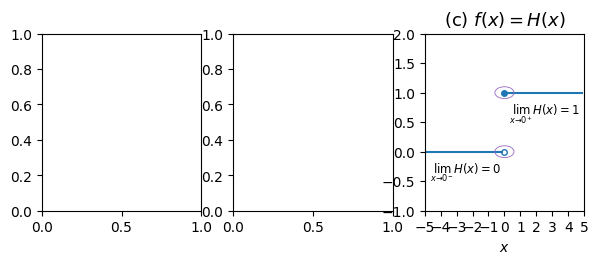

In [8]:
# FIGURES ONLY
import matplotlib.pylab as plt
from ministats.calculus import plot_limit
from ministats.calculus import plot_ellipse

fig, axs = plt.subplots(1, 3, figsize=(7,2.3))
TITLE_FONT_SIZE = 13


# (c) Limits involving the Heaviside step function f(x) = H(x)
def H(x):
    if x >= 0:
        return 1
    else:
        return 0
ax = plot_limit(H, xlim=[[-5,0],[0,5]], eps=0.15, ylim=[-1,2], ax=axs[2])
ax.set_xticks([-5,-4,-3,-2,-1,0,1,2,3,4,5])
ax.set_xlabel("$x$")
ax.set_title("(c) $f(x) = H(x)$", fontsize=TITLE_FONT_SIZE)
# continuous point (filled circle)
ax.plot(0, 1, marker='o', markersize=4, color='C0')
# discontinuous point (open circle)
ax.plot(0, 0, marker='o', markersize=4, markerfacecolor='none', markeredgecolor='C0')
# ellipse annotation (from the left)
plot_ellipse(ax, 0, 0, 1.2, 0.2, lx=-0.2, ly=-0.35, ha="right",
             label=r"$\lim_{x \to 0^-} H(x) = 0$")
# ellipse annotation (from the right)
plot_ellipse(ax, 0, 1, 1.2, 0.2, lx=0.3, ly=0.65,
             label=r"$\lim_{x \to 0^+} H(x) = 1$")

#### Example 5 using SymPy

In [9]:
import sympy as sp
from sympy import Heaviside

x = sp.symbols("x")
sp.limit(Heaviside(x,1), x, 0, "-")

0

In [10]:
sp.limit(Heaviside(x,1), x, 0, "+")

1

## Multivariable calculus

In multivariable calculus,
we extend the ideas of differential and integral calculus
to functions with multiple input variables.


### Multivariable functions

Consider the bivariate function $f(x,y) = 4 - x^2 - \frac{1}{4}y^2$.

In [11]:
x, y = sp.symbols("x y")
fxy = 4 - x**2 - y**2/4
fxy

-x**2 - y**2/4 + 4

We can plot this function as a *surface* in a three-dimensional space.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

xmax = 2.01
ymax = 4.02

xs = np.linspace(-xmax, xmax, 300)
ys = np.linspace(-ymax, ymax, 300)
X, Y = np.meshgrid(xs, ys)
Z = 4 - X**2 - Y**2/4

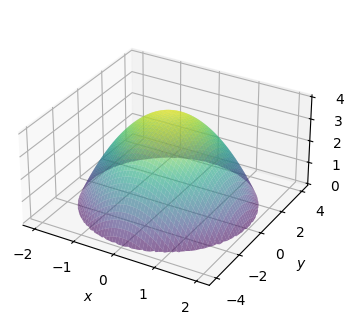

In [13]:
# Surface plot
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection="3d")
Zpos = np.ma.masked_where(Z < 0, Z)
surf = ax.plot_surface(X, Y, Zpos,
                       # rstride=3, cstride=3,
                       alpha=0.6,
                       linewidth=0.1,
                       antialiased=True,
                       cmap="viridis")
ax.set_box_aspect((2, 2, 1))
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$f(x,y)$");

We can trace *level curves* in the surface,
to produce a "topographic map" of the surface
where each level curve shows the points that are at a certain height.

Text(0, 0.5, '$y$')

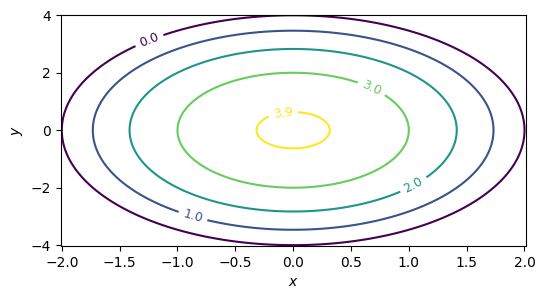

In [14]:
# Contour plot
fig, ax = plt.subplots(figsize=(6,3))
cplot = ax.contour(X, Y, Z,
                   levels=[0,1,2,3,3.9],
                   cmap="viridis")
plt.clabel(cplot, inline=1, fontsize=9)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

### Partial derivatives

In [15]:
sp.diff(fxy, x)

-2*x

In [16]:
sp.diff(fxy, y)

-y/2

### The gradient operator

In [17]:
[sp.diff(fxy, x), sp.diff(fxy, y)]

[-2*x, -y/2]

### Partial integration

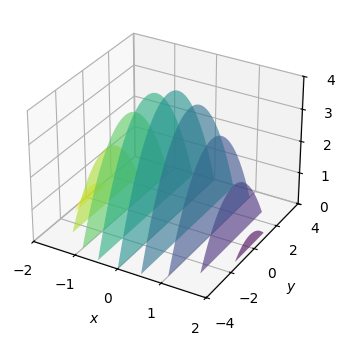

In [18]:
from ministats.calculus import plot_slices_through_paraboloid

plot_slices_through_paraboloid(direction="x");

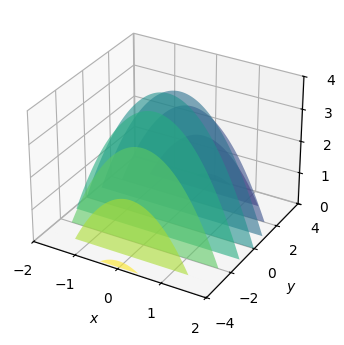

In [19]:
plot_slices_through_paraboloid(direction="y");

### Double integrals

The multivariable generalization of the integral $\int_a^b f(x) \, dx$
that computes the total amount of $f(x)$ between $a$ and $b$
is the multivariable integral of the form:

$$
    \int \! \int_{(x,y) \in R} f(x,y) \, dxdy,
$$

where $R$ is called the *region of integration*
and corresponds to some subset of the Cartesian plane $\mathbb{R} \times \mathbb{R}$.


### Applications of multivariable calculus

Multivariable functions are used in machine learning,
engineering, physics, and other sciences. The optimization techniques we
learned for single variables functions generalize to
functions with multiple inputs.
Indeed, the *gradient descent algorithm*
is often used to optimize functions with hundreds or thousands of inputs.
Multivariable integrals
appear  in probability theory and statistics,
where they are used
to compute probabilities and expectations. Your basic knowledge of
derivatives and integrals concepts from this tutorial
will be very useful for understanding multivariable calculus topics.

## Vector calculus

### Example: electric field around a positive charge

The strength of the electric field $\mathbf{E}$ 
at the point $\mathbf{r} = (x,y,z)$ is

$$
    \mathbf{E}(x,y,z)
        = \frac{kq}{(x^2 + y^2 + z^2)^{3/2}}(x,y,z)
        = \frac{kq}{r^3}  \mathbf{r}
        = \frac{kq}{r^2} \hat{ \mathbf{r} },
$$

where $k$ is Coulomb's constant,
$r = \sqrt{x^2+y^2+z^2}$ is the distance from the origin,
and $\hat{\mathbf{r}} = \frac{\mathbf{r}}{r}$
is a *unit vector* in the same direction as $\mathbf{r}$.


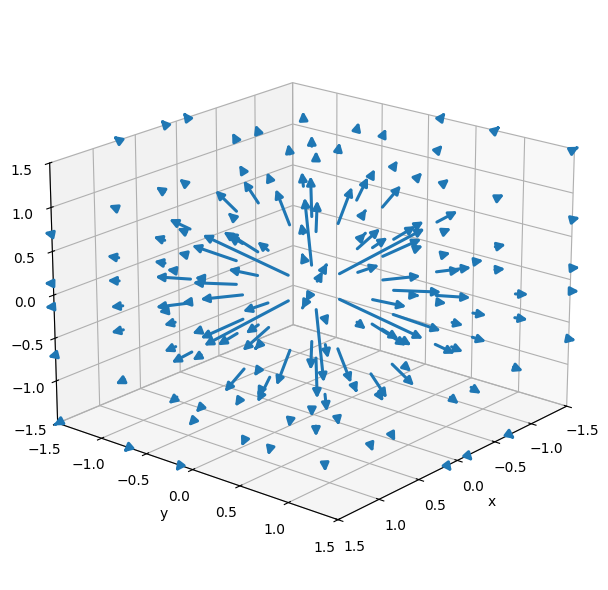

In [20]:
from ministats.calculus import plot_point_charge_field

plot_point_charge_field(elev=20, azim=40, grid_lim=1.5, n_points=6);

### Vector calculus derivatives

The derivative operator $\nabla$ (*nabla*) is defined as
$\nabla = \big( \frac{\partial}{\partial x}, \frac{\partial}{\partial y}, \frac{\partial}{\partial z} \big)$.

The *divergence* of the vector field $\mathbf{F}$ is computed by taking
the "dot product" of $\nabla$ and the vector field $\mathbf{F} = (F_x, F_y, F_z)$:

$$\nabla \cdot \mathbf{F}(x,y,z)
                = \frac{\partial F_x}{\partial x}   + \frac{\partial F_y}{\partial y}   + \frac{\partial F_z}{\partial z}.$$

The divergence tells us if the field $\mathbf{F}$ is acting as a
"source" or a "sink" at the point $(x,y,z)$.

The *curl* of the vector field $\mathbf{F}$ is defined as the "cross
product" of $\nabla$ and the vector field $\mathbf{F} = (F_x, F_y, F_z)$:

$$\nabla \times \mathbf{F}(x,y,z)
                =   \left(
                        \frac{\partial F_z}{\partial y} - \frac{\partial F_y}{\partial z}, \;\;
                        \frac{\partial F_x}{\partial z} - \frac{\partial F_z}{\partial x}, \;\;
                        \frac{\partial F_y}{\partial x} - \frac{\partial F_x}{\partial y}
                    \right)\!.$$ 
                    
The curl tells us the rotational
tendency of the vector field $\mathbf{F}$.


### Vector calculus integrals

#### Path integrals
The concept of a vector path integral is denoted
$\int_C \mathbf{F}(\mathbf{r}) \cdot d\mathbf{r}$, where $C$ is some
curve in three dimensional space, and $d\mathbf{r}$ describes a short
step along this curve. This integral computes the total action of the
vector field $\mathbf{F}$ in the direction along the curve $C$. 

#### Surface integrals
The vector surface integral is denoted
$\iint_S \mathbf{F}(\mathbf{r}) \cdot d\mathbf{S}$, where $S$ is some
surface in three dimensional space, and $d\mathbf{S}$ is a small "piece
of the surface." This integral computes the total *flux* of the vector
field $\mathbf{F}$ flowing through the surface $S$.

### Applications of vector calculus

Vector calculus is used in physics and electrical engineering.

#### Taylor series of $e^x$

In [21]:
import sympy as sp
x, k = sp.symbols("x k")

# first derivative of e^x at x=0
sp.diff(sp.exp(x), x, 1).subs({x:0})

1

In [22]:
# second derivative of e^x at x=0
sp.diff(sp.exp(x), x, 2).subs({x:0})

1

In [23]:
# fifth derivative of e^x at x=0
sp.diff(sp.exp(x), x, 5).subs({x:0})

1

In [24]:
exp_c_k = x**k / sp.factorial(k)
sp.Sum(exp_c_k, (k,0,7))

Sum(x**k/factorial(k), (k, 0, 7))

In [25]:
sp.Sum(exp_c_k, (k,0,7)).doit()

x**7/5040 + x**6/720 + x**5/120 + x**4/24 + x**3/6 + x**2/2 + x + 1

In [26]:
sp.summation( exp_c_k.subs({x:0}), (k,0,sp.oo))

1

This is the value $\exp(0) = e^0 = 1$.

We can also compute $e^5$:

In [27]:
sp.summation( exp_c_k.subs({x:5}), (k,0,sp.oo))

exp(5)

### Bonus question

Compute the definite integral $\int_{-\infty}^\infty e^{-x^2}\,dx$
numerically using the `quad` function.

In [28]:
import numpy as np
from scipy.integrate import quad


def expxsq(x):
    return np.exp(-x**2)

quad(expxsq, a=-np.inf, b=np.inf)[0]

1.7724538509055159